# Insurance Charges Prediction using Linear Regression

In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import linear_model

# DATA ACQUISITION & INSPECTION

In [37]:
path = r"Data\insurance.csv"
df = pd.read_csv(path)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Data Loading and Initial Preview

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# Metadata and Structure Inspection

In [39]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Checking Columns

In [40]:
df.columns
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

# Data Validation

In [41]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [42]:
df['charges']

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

# Exploratory Data Analysis (EDA)

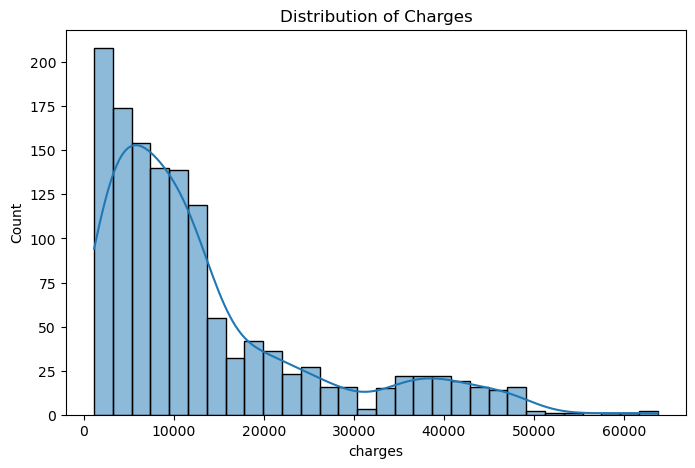

In [43]:
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Charges")
plt.show()

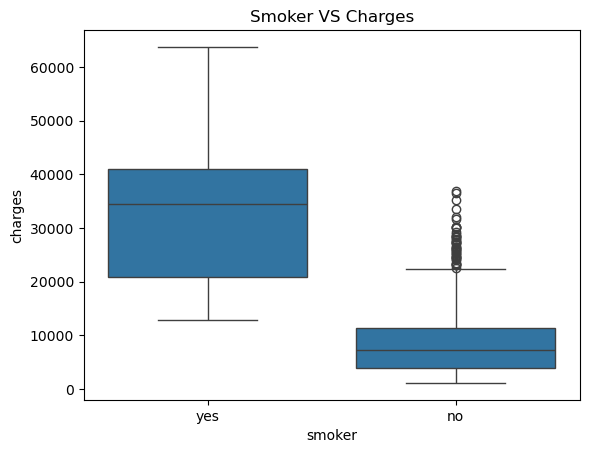

In [44]:
sns.boxplot(x = 'smoker', y = 'charges', data=df)
plt.title("Smoker VS Charges")
plt.show()

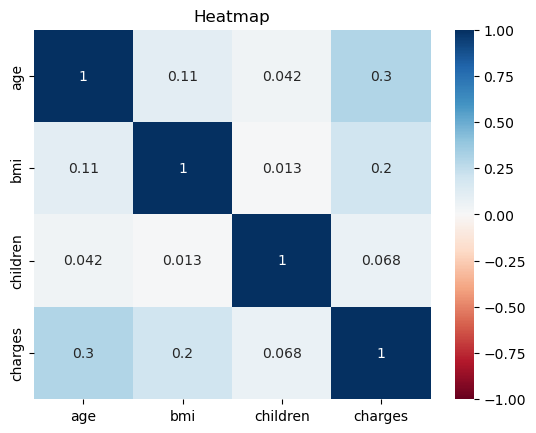

In [45]:
sns.heatmap(df.corr(numeric_only=True), vmin = -1, vmax = 1, annot=True, cmap='RdBu')
plt.title('Heatmap')
plt.show()

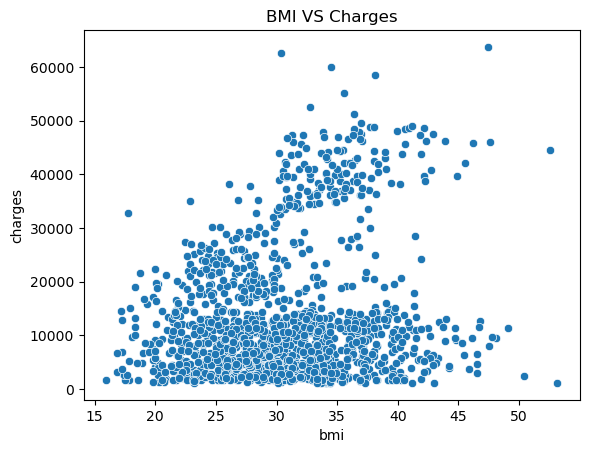

In [46]:
sns.scatterplot(x = 'bmi', y = 'charges', data = df)
plt.title('BMI VS Charges')
plt.show()

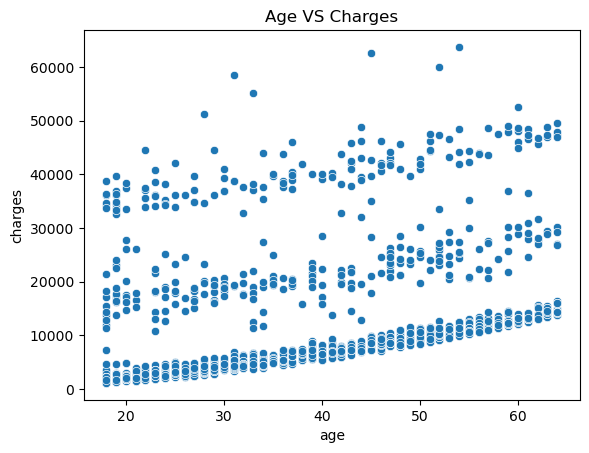

In [47]:
sns.scatterplot(x = 'age', y = 'charges', data = df)
plt.title('Age VS Charges')
plt.show()

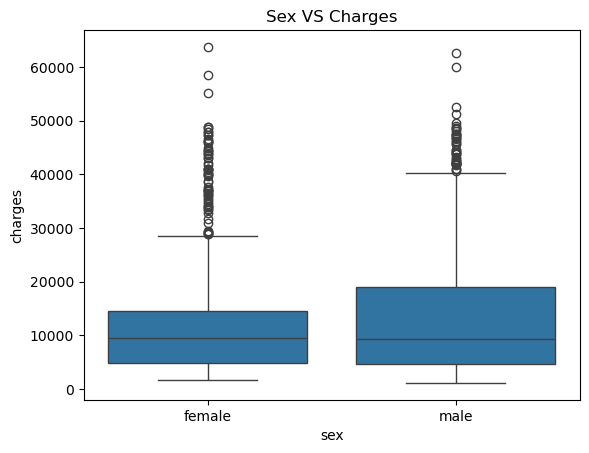

In [48]:
sns.boxplot(x = 'sex', y = 'charges', data = df)
plt.title('Sex VS Charges')
plt.show()

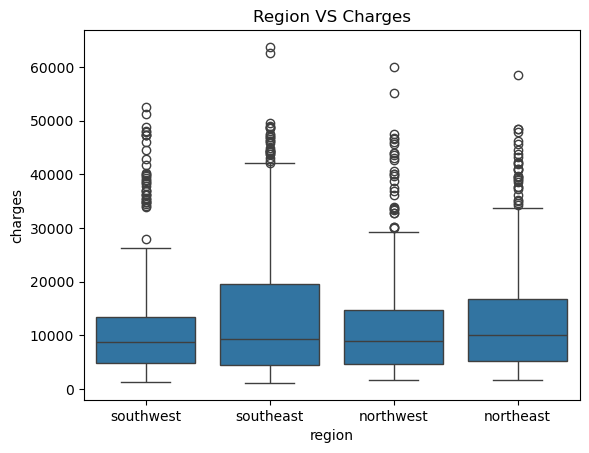

In [49]:
sns.boxplot(x = 'region', y = 'charges', data = df)
plt.title('Region VS Charges')
plt.show()

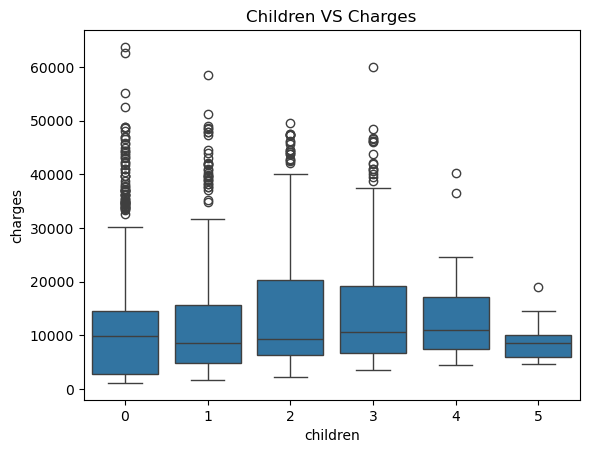

In [50]:
sns.boxplot(x = 'children', y = 'charges', data = df)
plt.title('Children VS Charges')
plt.show()

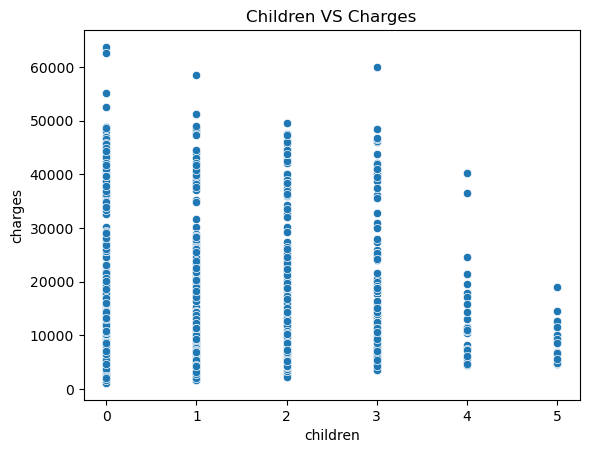

In [51]:
sns.scatterplot(x = 'children', y = 'charges', data = df)
plt.title('Children VS Charges')
plt.show()

# FEATURE ENGINEERING

In [52]:
df["age_smoker"] = df["age"] * (df["smoker"] == "yes").astype(int)
df["bmi_smoker"] = df["bmi"] * (df["smoker"] == "yes").astype(int)

# Features and Target Defining

In [53]:
X = df.drop("charges", axis=1)
y = df["charges"]

# Identifying Numeric aur Categorical Columns

In [54]:
numeric_features = ["age", "bmi", "children", "age_smoker", "bmi_smoker"]
categorical_features = ["sex", "smoker", "region"]

# Train-test Split

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessing Pipelines

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# ColumnTransformer

In [57]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Full Model Pipeline

In [58]:
from sklearn.linear_model import LinearRegression

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [59]:
from sklearn.compose import TransformedTargetRegressor
import numpy as np

model = TransformedTargetRegressor(
    regressor=model_pipeline,
    func=np.log,
    inverse_func=np.exp
)

# Model Training

In [60]:
model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Predictions

In [61]:
y_pred = model_pipeline.predict(X_test)

print(y_pred[:5])

[11244.92252985  7419.09613036 33108.56263345 10825.70349972
 28165.83120369]


# Evaluation

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2757.759204250125
MSE: 20922607.93807084
RMSE: 4574.123734451315
R2 Score: 0.865231697953168


# Actual vs Predicted Plot

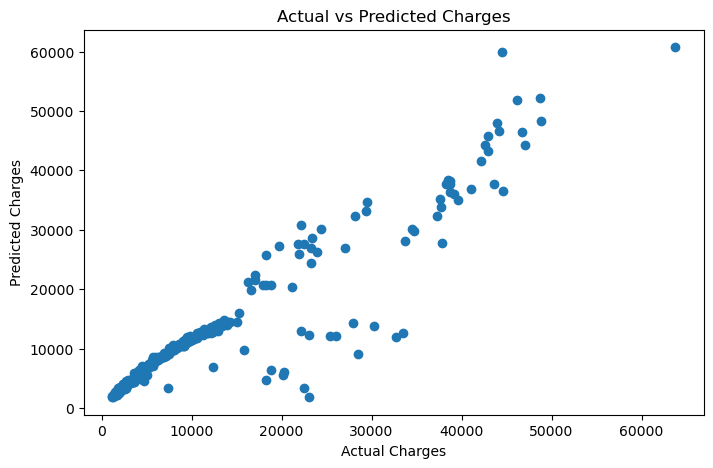

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()

# Residual Check

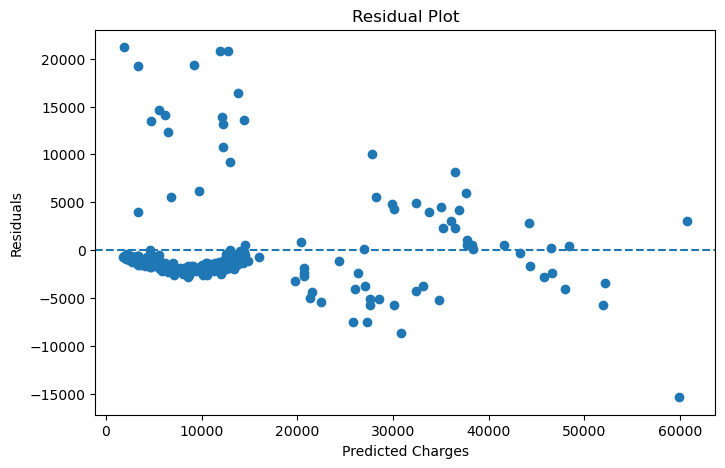

In [64]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# Entire Pipeline Save

In [65]:
import pickle

with open("insurance_linear_regression_pipeline.pkl", "wb") as f:
    pickle.dump(model_pipeline, f)

In [66]:
!jupyter nbconvert --to script *.ipynb

[NbConvertApp] Converting notebook Insurance Charges Prediction.ipynb to script
[NbConvertApp] Writing 4940 bytes to Insurance Charges Prediction.py


In [69]:
!pipreqs . --force

Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
INFO: Successfully saved requirements file in .\requirements.txt


In [68]:
with open(".gitignore", "w") as f:
    f.write("""# Python
__pycache__/
*.pyc
*.pyo
*.pyd

# Jupyter
.ipynb_checkpoints/

# Virtual Environment
venv/
env/

# Environment Variables
.env

# OS Files
.DS_Store
Thumbs.db
""")
